In [1]:
import gymnasium as gym


import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [3]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1


epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []

def epsilon_greedy_action(state, epsilon):
      if np.random.random() < epsilon:

          return env.action_space.sample()
      else:
                                  # Exploit
           return np.argmax(Q[state])



In [5]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [6]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

epsilon = epsilon_start

for episode_num in range(num_episodes):

    # Generate an episode
    episode = generate_episode(epsilon)

    # Calculate total reward
    total_reward = sum(reward for _, _, reward in episode)
    episode_rewards.append(total_reward)

    # Monte Carlo update
    G = 0

    for state, action, reward in reversed(episode):

        G = gamma * G + reward

        # Incremental update of Q-value
        Q[state, action] += alpha * (G - Q[state, action])

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    # Optional progress display
    if (episode_num + 1) % 2000 == 0:
        print(
            f"Episode {episode_num + 1}/{num_episodes}, "
            f"Epsilon: {epsilon:.4f}"
        )

Episode 2000/20000, Epsilon: 0.3678
Episode 4000/20000, Epsilon: 0.1353
Episode 6000/20000, Epsilon: 0.0500
Episode 8000/20000, Epsilon: 0.0500
Episode 10000/20000, Epsilon: 0.0500
Episode 12000/20000, Epsilon: 0.0500
Episode 14000/20000, Epsilon: 0.0500
Episode 16000/20000, Epsilon: 0.0500
Episode 18000/20000, Epsilon: 0.0500
Episode 20000/20000, Epsilon: 0.0500


In [7]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [10]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:vishwa v")
    print("Register Number:212224110062")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.    0.089 0.    0.   ]
 [0.    0.09  0.    0.   ]
 [0.    0.    0.322 0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.004 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.257 0.004 0.004 0.002]
 [0.    0.    0.    0.   ]
 [0.001 0.065 0.    0.052]
 [0.024 0.018 0.1   0.018]
 [0.288 0.093 0.06  0.029]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.076 0.073 0.079 0.179]
 [0.154 0.604 0.308 0.294]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.089 0.09  0.322 0.   ]
 [0.004 0.    0.257 0.   ]
 [0.065 0.1   0.288 0.   ]
 [0.    0.179 0.604 0.   ]]
Name:vishwa v
Register Number:212224110062

Learned Policy:
[['D' 'D' 'R' 'R']
 ['D' 'L' 'L' 'L']
 ['D' 'R' 'L' 'L']
 ['L' 'U' 'D' 'L']]

Average reward over last 1000 episodes: 0.046


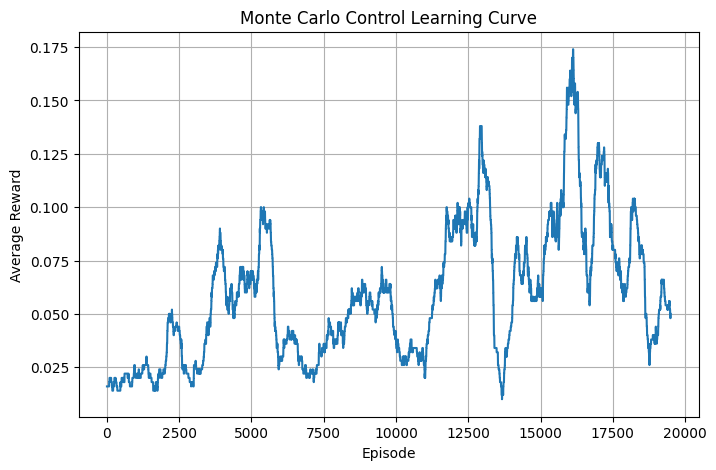

In [9]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()